<a href="https://colab.research.google.com/github/cloudiesca/Metode-Numerik_Desca-Rahma-Kholisa/blob/main/proof_of_concept_kelompok11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install librosa kagglehub tensorflow scikit-learn seaborn

In [11]:
import os
import json
import librosa
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import GRU
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [12]:
path = kagglehub.dataset_download(
    "eoinedge/ai-mechanic-engine-condition-audio-fault-finding"
)

print(path)

Using Colab cache for faster access to the 'ai-mechanic-engine-condition-audio-fault-finding' dataset.
/kaggle/input/ai-mechanic-engine-condition-audio-fault-finding


In [13]:
def extract_features(audio_path):

    y, sr = librosa.load(
        audio_path,
        sr=16000
    )

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=20
    )

    mfcc_mean = np.mean(
        mfcc,
        axis=1
    )

    return mfcc_mean

In [14]:
json_file = os.path.join(
    path,
    "ai-mechanic-export",
    "info.labels"
)

with open(json_file) as f:
    metadata = json.load(f)

X = []
y = []

for item in metadata["files"]:

    if item["category"] != "training":
        continue

    label = item["label"]["label"].lower()

    if "background noise" in label:
        continue

    audio_path = os.path.join(
        path,
        "ai-mechanic-export",
        item["path"]
    )

    features = extract_features(
        audio_path
    )

    # NORMAL
    if (
        "idling" in label
        or "normal engine" in label
    ):
        target = 0

    # FAULT
    elif (
        "air leak" in label
        or "oil cap off" in label
    ):
        target = 1

    else:
        continue

    X.append(features)
    y.append(target)

X = np.array(X)
y = np.array(y)

print("Samples :", len(X))
print("Normal :", np.sum(y==0))
print("Fault :", np.sum(y==1))

Samples : 27
Normal : 10
Fault : 17


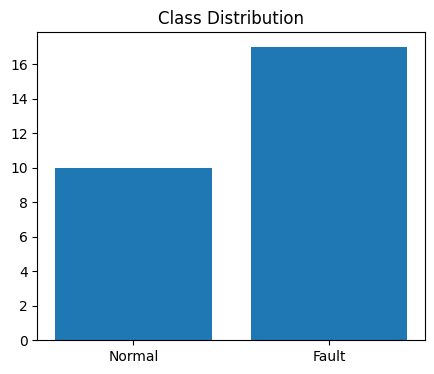

In [15]:
plt.figure(figsize=(5,4))

plt.bar(
    ["Normal","Fault"],
    [
        np.sum(y==0),
        np.sum(y==1)
    ]
)

plt.title("Class Distribution")
plt.show()

In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(
    n_components=10
)

X_pca = pca.fit_transform(
    X_scaled
)

print(X_pca.shape)

(27, 10)


In [17]:
X_pca = X_pca.reshape(
    X_pca.shape[0],
    X_pca.shape[1],
    1
)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=3,
        activation='relu',
        input_shape=(
            X_train.shape[1],
            1
        )
    )
)

model.add(
    MaxPooling1D(
        pool_size=2
    )
)

model.add(
    GRU(16)
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        8,
        activation='relu'
    )
)

model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 8, 32)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 16)             │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,673 (10.44 KB)

 Trainable params: 2,673 (10.44 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=4,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 152ms/step - accuracy: 0.6875 - loss: 0.6794 - val_accuracy: 0.6000 - val_loss: 0.6988
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6250 - loss: 0.6787 - val_accuracy: 0.6000 - val_loss: 0.6985
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6250 - loss: 0.6845 - val_accuracy: 0.6000 - val_loss: 0.7002
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6875 - loss: 0.6736 - val_accuracy: 0.6000 - val_loss: 0.6991
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6250 - loss: 0.6631 - val_accuracy: 0.6000 - val_loss: 0.6980
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6875 - loss: 0.6637 - val_accuracy: 0.6000 - val_loss: 0.7000
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6250 - loss: 0.6620 - val_accuracy: 0.6000 - val_loss: 0.6972
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6875 - loss: 0.6677 - val_accuracy: 0.6000 - val_loss: 0.6947

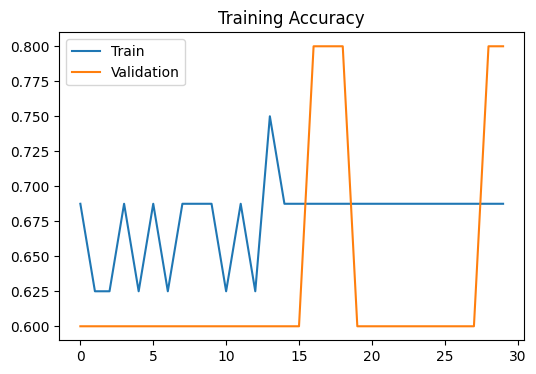

In [21]:
plt.figure(figsize=(6,4))

plt.plot(
    history.history['accuracy'],
    label='Train'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation'
)

plt.legend()
plt.title("Training Accuracy")
plt.show()

In [22]:
pred = model.predict(
    X_test
)

pred = (
    pred > 0.5
).astype(int)

print(
    classification_report(
        y_test,
        pred
    )
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 799ms/step
              precision    recall  f1-score   support

           0       0.33      0.50      0.40         2
           1       0.67      0.50      0.57         4

    accuracy                           0.50         6
   macro avg       0.50      0.50      0.49         6
weighted avg       0.56      0.50      0.51         6



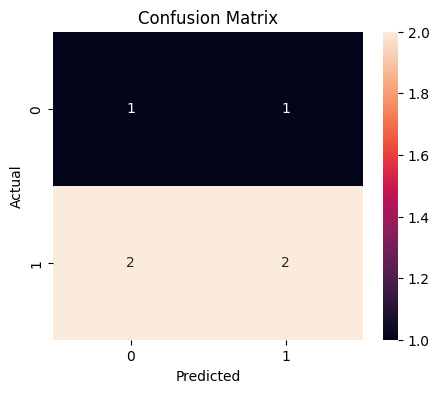

In [23]:
cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [25]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

with open(
    "engine_fault_model.tflite",
    "wb"
) as f:

    f.write(tflite_model)

print("TFLite model berhasil dibuat")

Saved artifact at '/tmp/tmp8cmml_pg'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137087787260176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137087787261712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137087588492944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137087588493328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137087588497168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137087588494480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137087586306576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137087804161104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137087787254992: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model berhasil dibuat


In [27]:
model.save("model.h5")

import os

h5_size = os.path.getsize("model.h5")
tflite_size = os.path.getsize("engine_fault_model.tflite")

print(
    "Original Model:",
    round(h5_size/1024,2),
    "KB"
)

print(
    "TFLite Model:",
    round(tflite_size/1024,2),
    "KB"
)

Original Model: 73.27 KB
TFLite Model: 24.15 KB
